# Protein–İlaç Bağlanma Afinitesi Projesi 

1. VSCode'u aç, Extensions'tan **Python** ve **Jupyter** eklentilerini kur
2. Bu dosyanın bulunduğu klasörde bir terminal aç (Terminal > New Terminal)
3. Sanal ortam oluştur ve aktive et:
   - Windows: `python -m venv venv` sonra `venv\Scripts\activate`
   - Mac/Linux: `python3 -m venv venv` sonra `source venv/bin/activate`
4. Kütüphaneleri kur: `pip install pandas numpy rdkit scikit-learn xgboost lightgbm scipy matplotlib seaborn jupyter`
5. Bu `.ipynb` dosyasını VSCode'da aç, sağ üstten kernel olarak oluşturduğun `venv`'i seç

protein_ilac_projesi/
  protein_ilac_baslangic.ipynb
  data/
    BindingDB_All.tsv
    kiba_all.csv
    davis_all.csv
```


## 1. Kütüphaneleri Import Et

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

print("Kütüphaneler hazır.")

Kütüphaneler hazır.


## 2. Dosya Yollarını Tanımla

In [191]:
DATA_DIR = 'data/'
# Kendi dosya adlarına göre bu yolları güncelle
BINDINGDB_PATH = DATA_DIR + 'BindingDB_All.tsv'
KIBA_PATH = DATA_DIR + 'kiba_all.csv'
DAVIS_PATH = DATA_DIR + 'davis_all.csv'

## 3. Verileri Yükle ve İlk Bakış

Her dosyanın sütun isimleri farklı olacak — önce `.head()` ve `.columns` ile yapıyı gör, sonra ihtiyacın olan sütunları seç.

In [192]:
# BindingDB genelde çok geniş ve TSV formatında gelir, sadece ihtiyacımız olan sütunları okuyalım
usecols = ['Ligand SMILES', 'Target Name', 'Ki (nM)', 'IC50 (nM)', 'Kd (nM)']

chunks = []
for chunk in pd.read_csv(BINDINGDB_PATH, sep='\t', usecols=usecols,
                          chunksize=100_000, low_memory=False, on_bad_lines='skip'):
    mask = chunk['Target Name'].astype(str).str.contains('kinase', case=False, na=False)
    filtered = chunk[mask]
    if not filtered.empty:
        chunks.append(filtered)

bindingdb = pd.concat(chunks, ignore_index=True)
print(bindingdb.shape)
bindingdb.head()

(721649, 5)


,Ligand SMILES,Target Name,Ki (nM),IC50 (nM),Kd (nM)
0,O=C1CCCC2=C1C1(CCS(=O)(=O)C1)N=C(Nc1nc3ccccc3o...,Galactokinase,NaN,6676.9,NaN
1,Cn1c2ncn(CCO)c(=O)c2c(Nc2ccc(I)cc2F)cc1=O,Dual specificity mitogen-activated protein kin...,NaN,10,NaN
2,Cn1c2ncn(C[C@H](O)CO)c(=O)c2c(Nc2ccc(I)cc2F)cc...,Dual specificity mitogen-activated protein kin...,NaN,10,NaN
3,Cc1c(Nc2ccc(I)cc2F)c2c(ncn(C[C@@H](O)CO)c2=O)n...,Dual specificity mitogen-activated protein kin...,NaN,<5,NaN
4,Cc1c(Nc2ccc(Br)cc2F)c2c(ncn(C[C@H](O)CO)c2=O)n...,Dual specificity mitogen-activated protein kin...,NaN,>16,NaN


In [193]:
kiba = pd.read_csv(KIBA_PATH)
davis = pd.read_csv(DAVIS_PATH)

print("KIBA:", kiba.shape)
display(kiba.head())
print("Davis:", davis.shape)
display(davis.head())

KIBA: (118254, 3)


,compound_iso_smiles,target_sequence,affinity
0,O=C1c2c(c3c4ccc(O)cc4n(C4OC(CO)C(O)C(O)C4O)c3c...,MSANNSPPSAQKSVLPTAIPAVLPAASPCSSPKTGLSARLSNGSFS...,9.798970
1,N#Cc1ccc(NC(=O)Nc2ccnc3cc(C(F)(F)F)ccc23)nc1,MLGAVEGPRWKQAEDIRDIYDFRDVLGTGAFSEVILAEDKRTQKLV...,11.400000
2,CCNc1nc2cc(Cl)c(OC)cc2nc1NCC,MEPAAGFLSPRPFQRAAAAPAPPAGPGPPPSALRGPELEMLAGLPT...,11.200000
3,CNc1ncnc2c1N=C(c1ccc(NC(=O)Nc3cccc(C(F)(F)F)c3...,MELRVGNRYRLGRKIGSGSFGDIYLGTDIAAGEEVAIKLECVKTKH...,11.200000
4,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,MRGARGAWDFLCVLLLLLRVQTGSSQPSVSPGEPSPPSIHPGKSDL...,11.999998


Davis: (30056, 3)


,compound_iso_smiles,target_sequence,affinity
0,O=C(NC1CCNCC1)c1[nH]ncc1NC(=O)c1c(Cl)cccc1Cl,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...,5.0
1,CSc1cccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3...,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,5.0
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,MGPAPLPLLLGLFLPALWRRAITEAREEAKPYPLFPGPFPGSLQTD...,5.0
3,COC1C(N(C)C(=O)c2ccccc2)CC2OC1(C)n1c3ccccc3c3c...,MFRKKKKKRPEISAPQNFQHRVHTSFDPKEGKFVGLPPQWQNILDT...,5.0
4,CN(C)CC=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc...,TMPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLITI...,5.0


## 4. RDKit ile Molekül Özellikleri Hesaplama

Bu fonksiyon bir SMILES string'inden MW, LogP, TPSA, HBD, HBA, Rotatable Bonds çıkarır. Geçersiz SMILES için `None` döner (bunlar sonra silinecek).

In [194]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series({
            'MW': None, 'LogP': None, 'TPSA': None,
            'HBD': None, 'HBA': None, 'RotBonds': None
        })
    return pd.Series({
        'MW': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'TPSA': rdMolDescriptors.CalcTPSA(mol),
        'HBD': rdMolDescriptors.CalcNumHBD(mol),
        'HBA': rdMolDescriptors.CalcNumHBA(mol),
        'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(mol)
    })

# Örnek kullanım:
# df[['MW','LogP','TPSA','HBD','HBA','RotBonds']] = df['SMILES'].apply(compute_descriptors)

## 5. Ortak Formatı Oluştur

Her kaynaktan gelen veriyi aynı şablona (SMILES, protein, affinity_value, measurement_type, source) döküyoruz. Şu an sütun isimleri placeholder — kendi dosyalarına göre güncelle.

In [195]:
# --- BindingDB: Ki, IC50, Kd sütunlarını tek "affinity_value" sütununa indiriyoruz ---
bdb_long = bindingdb.melt(
    id_vars=['Ligand SMILES', 'Target Name'],
    value_vars=['Ki (nM)', 'IC50 (nM)', 'Kd (nM)'],
    var_name='measurement_type', value_name='affinity_value'
)
bdb_long = bdb_long.dropna(subset=['affinity_value'])
bdb_long.columns = ['SMILES', 'protein', 'measurement_type', 'affinity_value']
bdb_long['source'] = 'BindingDB'

# --- Davis: affinity zaten pKd (log ölçek), doğrudan pKi olarak kullanıyoruz ---
davis_clean = davis[['compound_iso_smiles', 'target_sequence', 'affinity']].copy()
davis_clean.columns = ['SMILES', 'protein', 'pKi']
davis_clean['source'] = 'Davis'

# --- KIBA: farklı bir ölçek (KIBA score), pKi'den ayrı tutuyoruz ---
kiba_clean = kiba[['compound_iso_smiles', 'target_sequence', 'affinity']].copy()
kiba_clean.columns = ['SMILES', 'protein', 'KIBA_score']
kiba_clean['source'] = 'KIBA'

print("BindingDB (uzun format):", bdb_long.shape)
print("Davis:", davis_clean.shape)
print("KIBA:", kiba_clean.shape)
bdb_long.head()

BindingDB (uzun format): (694000, 5)
Davis: (30056, 4)
KIBA: (118254, 4)


,SMILES,protein,measurement_type,affinity_value,source
1930,Nc1nc(OCC2CCCCC2)c2[nH]cnc2n1,Cyclin-dependent kinase 1/G2/mitotic-specific ...,Ki (nM),5000,BindingDB
1933,C1CCC(CC1)COc2c(c(nc(n2)N)N)N=O,Cyclin-dependent kinase 1/G2/mitotic-specific ...,Ki (nM),2500,BindingDB
1935,Nc1nc(OCC2CCCCC2)c2[nH]cnc2n1,Cyclin-A2 [171-432]/Cyclin-dependent kinase 2,Ki (nM),12000,BindingDB
1938,C1CCC(CC1)COc2c(c(nc(n2)N)N)N=O,Cyclin-A2 [171-432]/Cyclin-dependent kinase 2,Ki (nM),1300,BindingDB
4346,Cc1nc(Nc2[nH]nc3c2CN(C(=O)N[C@@H]2C[C@H]2c2ccc...,Serine/threonine-protein kinase PAK 4,Ki (nM),3.5,BindingDB


## 6. pKi Hesaplama (sadece Ki/Kd/IC50 nM cinsindeyse)

KIBA score farklı bir ölçek olduğu için doğrudan pKi'ye çevrilmez — ayrı tutup ayrı analiz etmek daha doğru.

In [196]:
def clean_numeric(val):
    if pd.isna(val):
        return None
    val = str(val).replace('<', '').replace('>', '').strip()
    try:
        return float(val)
    except ValueError:
        return None

bdb_long['affinity_value'] = bdb_long['affinity_value'].apply(clean_numeric)
bdb_long = bdb_long.dropna(subset=['affinity_value'])

def to_pki(value_nM):
    if value_nM is None or value_nM <= 0:
        return None
    return -np.log10(value_nM / 1e9)

bdb_long['pKi'] = bdb_long['affinity_value'].apply(to_pki)
bdb_long = bdb_long.dropna(subset=['pKi'])

print("BindingDB pKi hesaplandı:", bdb_long.shape)
bdb_long[['SMILES', 'protein', 'pKi', 'source']].head()

BindingDB pKi hesaplandı: (693958, 6)


,SMILES,protein,pKi,source
1930,Nc1nc(OCC2CCCCC2)c2[nH]cnc2n1,Cyclin-dependent kinase 1/G2/mitotic-specific ...,5.301030,BindingDB
1933,C1CCC(CC1)COc2c(c(nc(n2)N)N)N=O,Cyclin-dependent kinase 1/G2/mitotic-specific ...,5.602060,BindingDB
1935,Nc1nc(OCC2CCCCC2)c2[nH]cnc2n1,Cyclin-A2 [171-432]/Cyclin-dependent kinase 2,4.920819,BindingDB
1938,C1CCC(CC1)COc2c(c(nc(n2)N)N)N=O,Cyclin-A2 [171-432]/Cyclin-dependent kinase 2,5.886057,BindingDB
4346,Cc1nc(Nc2[nH]nc3c2CN(C(=O)N[C@@H]2C[C@H]2c2ccc...,Serine/threonine-protein kinase PAK 4,8.455932,BindingDB


In [197]:
# BindingDB (pKi) + Davis (pKi) birleştir
combined = pd.concat([
    bdb_long[['SMILES', 'protein', 'pKi', 'source']],
    davis_clean[['SMILES', 'protein', 'pKi', 'source']]
], ignore_index=True)

print("Birleşmiş veri (RDKit öncesi):", combined.shape)

# Her benzersiz molekül için bir kere descriptor hesaplıyoruz (aynı molekül çok satırda tekrar ediyor, hız için)
unique_smiles = combined['SMILES'].dropna().unique()
print("Benzersiz molekül sayısı:", len(unique_smiles))

desc_df = pd.DataFrame({'SMILES': unique_smiles})
desc_df[['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds']] = desc_df['SMILES'].apply(compute_descriptors)

combined = combined.merge(desc_df, on='SMILES', how='left')
combined = combined.dropna(subset=['MW'])  # geçersiz SMILES'leri temizle

print("RDKit sonrası:", combined.shape)
combined.head()

Birleşmiş veri (RDKit öncesi): (724014, 4)
Benzersiz molekül sayısı: 291003


[00:51:18] Explicit valence for atom # 26 N, 4, is greater than permitted
[00:52:08] Explicit valence for atom # 23 N, 4, is greater than permitted
[00:52:10] Explicit valence for atom # 24 N, 4, is greater than permitted
[00:52:10] Explicit valence for atom # 24 N, 4, is greater than permitted
[00:52:11] Can't kekulize mol.  Unkekulized atoms: 2 3 4 30 32
[00:52:11] Explicit valence for atom # 25 N, 4, is greater than permitted
[00:52:21] Explicit valence for atom # 2 N, 4, is greater than permitted
[00:52:22] Explicit valence for atom # 22 N, 4, is greater than permitted
[00:52:24] Explicit valence for atom # 31 N, 4, is greater than permitted
[00:52:24] Explicit valence for atom # 1 N, 4, is greater than permitted
[00:53:41] Explicit valence for atom # 22 N, 4, is greater than permitted
[00:53:41] Explicit valence for atom # 22 N, 4, is greater than permitted
[00:53:41] Explicit valence for atom # 22 N, 4, is greater than permitted


RDKit sonrası: (723736, 10)


,SMILES,protein,pKi,source,MW,LogP,TPSA,HBD,HBA,RotBonds
0,Nc1nc(OCC2CCCCC2)c2[nH]cnc2n1,Cyclin-dependent kinase 1/G2/mitotic-specific ...,5.301030,BindingDB,247.302,1.89420,89.71,2.0,5.0,3.0
1,C1CCC(CC1)COc2c(c(nc(n2)N)N)N=O,Cyclin-dependent kinase 1/G2/mitotic-specific ...,5.602060,BindingDB,251.290,1.99800,116.48,2.0,7.0,4.0
2,Nc1nc(OCC2CCCCC2)c2[nH]cnc2n1,Cyclin-A2 [171-432]/Cyclin-dependent kinase 2,4.920819,BindingDB,247.302,1.89420,89.71,2.0,5.0,3.0
3,C1CCC(CC1)COc2c(c(nc(n2)N)N)N=O,Cyclin-A2 [171-432]/Cyclin-dependent kinase 2,5.886057,BindingDB,251.290,1.99800,116.48,2.0,7.0,4.0
4,Cc1nc(Nc2[nH]nc3c2CN(C(=O)N[C@@H]2C[C@H]2c2ccc...,Serine/threonine-protein kinase PAK 4,8.455932,BindingDB,459.579,4.78282,98.83,3.0,6.0,4.0


## 7. Temizlenmiş Veriyi Kaydet

In [198]:
# Aynı molekül-protein çifti birden fazla kez ölçülmüş olabilir, pKi ortalamasını alıyoruz
before = combined.shape[0]
combined = combined.groupby(['SMILES', 'protein', 'source'], as_index=False).agg({
    'pKi': 'mean',
    'MW': 'first', 'LogP': 'first', 'TPSA': 'first',
    'HBD': 'first', 'HBA': 'first', 'RotBonds': 'first'
})
print(f"Duplicate birleştirme öncesi: {before}, sonrası: {combined.shape[0]}")

# Eksik veri kontrolü
print(combined.isnull().sum())

# Kaydet
combined.to_csv(DATA_DIR + 'combined_clean.csv', index=False)
print("Kaydedildi:", combined.shape)

Duplicate birleştirme öncesi: 723736, sonrası: 539218
SMILES      0
protein     0
source      0
pKi         0
MW          0
LogP        0
TPSA        0
HBD         0
HBA         0
RotBonds    0
dtype: int64
Kaydedildi: (539218, 10)


## 8. EDA — Keşifçi Veri Analizi

In [199]:
combined = pd.read_csv(DATA_DIR + 'combined_clean.csv')
print(combined.shape)
combined.head()

(539218, 10)


,SMILES,protein,source,pKi,MW,LogP,TPSA,HBD,HBA,RotBonds
0,*C(C)(F)c1nc(CC)cc(Nc2cc(NC(C)=O)ncc2-c2cnc(OC...,Non-receptor tyrosine-protein kinase TYK2 [556...,BindingDB,8.000000,410.433,3.2931,114.81,2.0,8.0,7.0
1,B1([C@@H]2C[C@@H]2c3ccc(c(c3O1)C(=O)O)F)O,Urokinase-type plasminogen activator,BindingDB,3.000000,221.980,1.2543,66.76,2.0,3.0,1.0
2,B1([C@H](CC[C@H](O1)CC(=O)O)NC(=O)Cc2cccs2)O,Urokinase-type plasminogen activator,BindingDB,3.000000,297.141,0.4488,95.86,3.0,5.0,5.0
3,Bc1ccc(cc1)C1(CCCC1)c1csc(NC(=O)c2c(F)cc(cc2F)...,Alpha-protein kinase 1,BindingDB,5.752027,494.420,3.5439,48.47,1.0,5.0,5.0
4,BrC(Br)C(=O)c1ccc(I)cc1,Glycogen synthase kinase-3 beta,BindingDB,5.698970,403.839,3.5898,17.07,0.0,1.0,2.0


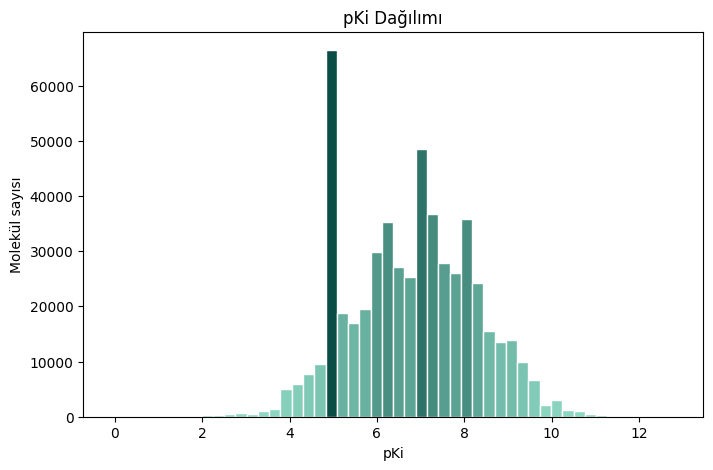

In [223]:
from matplotlib.colors import LinearSegmentedColormap

petrol_cmap = LinearSegmentedColormap.from_list('petrol_mint', ['#8FD9C4', '#0A4D47'])

plt.figure(figsize=(8, 5))

n, bins, patches = plt.hist(combined['pKi'], bins=50, edgecolor='white')

for count, patch in zip(n, patches):
    patch.set_facecolor(petrol_cmap(count / n.max()))

plt.xlabel('pKi')
plt.ylabel('Molekül sayısı')
plt.title('pKi Dağılımı')
plt.show()

In [201]:
combined [combined['pKi'] ==5.0] ['source'].value_counts()

source
BindingDB    40226
Davis        18343
Name: count, dtype: int64

In [202]:
combined[combined['pKi'] == 7.0]['source'].value_counts()

source
BindingDB    24144
Davis           35
Name: count, dtype: int64

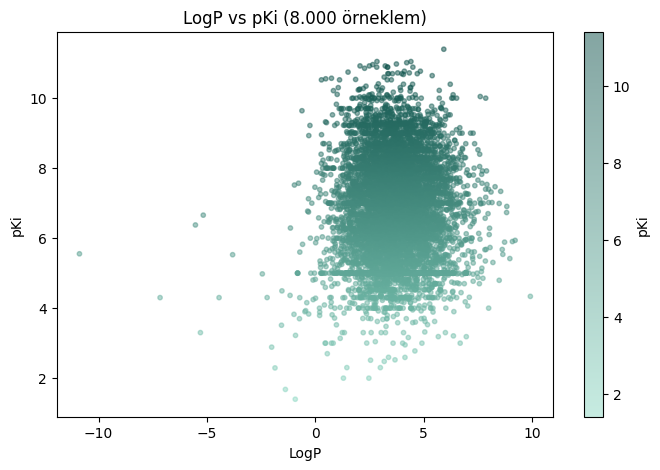

In [203]:
from matplotlib.colors import LinearSegmentedColormap

petrol_cmap = LinearSegmentedColormap.from_list('petrol_mint', ['#8FD9C4', '#0A4D47'])

sample = combined.sample(8000, random_state=42)

plt.figure(figsize=(8, 5))
sc = plt.scatter(sample['LogP'], sample['pKi'], alpha=0.5, s=10, c=sample['pKi'], cmap=petrol_cmap)
plt.colorbar(sc, label='pKi')
plt.xlabel('LogP')
plt.ylabel('pKi')
plt.title('LogP vs pKi (8.000 örneklem)')
plt.show()

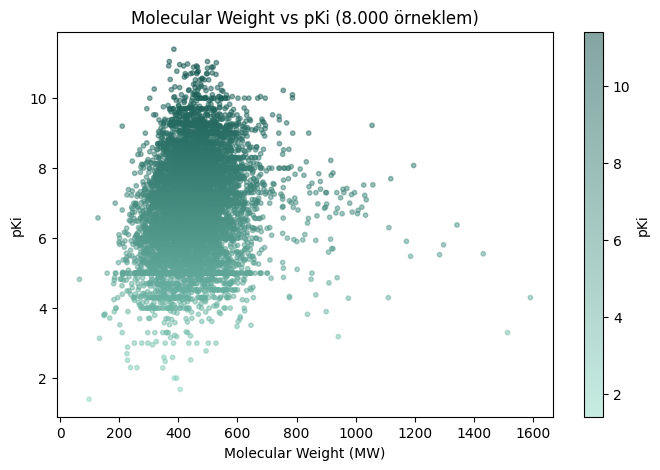

In [204]:
sample = combined.sample(8000, random_state=42)

plt.figure(figsize=(8, 5))
sc = plt.scatter(sample['MW'], sample['pKi'], alpha=0.5, s=10, c=sample['pKi'], cmap=petrol_cmap)
plt.colorbar(sc, label='pKi')
plt.xlabel('Molecular Weight (MW)')
plt.ylabel('pKi')
plt.title('Molecular Weight vs pKi (8.000 örneklem)')
plt.show()

/var/folders/nz/pcvk33f922jcn13vxxwlg8tm0000gn/T/ipykernel_36360/3497382324.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='pKi', y='protein', palette=petrol_tonlari)


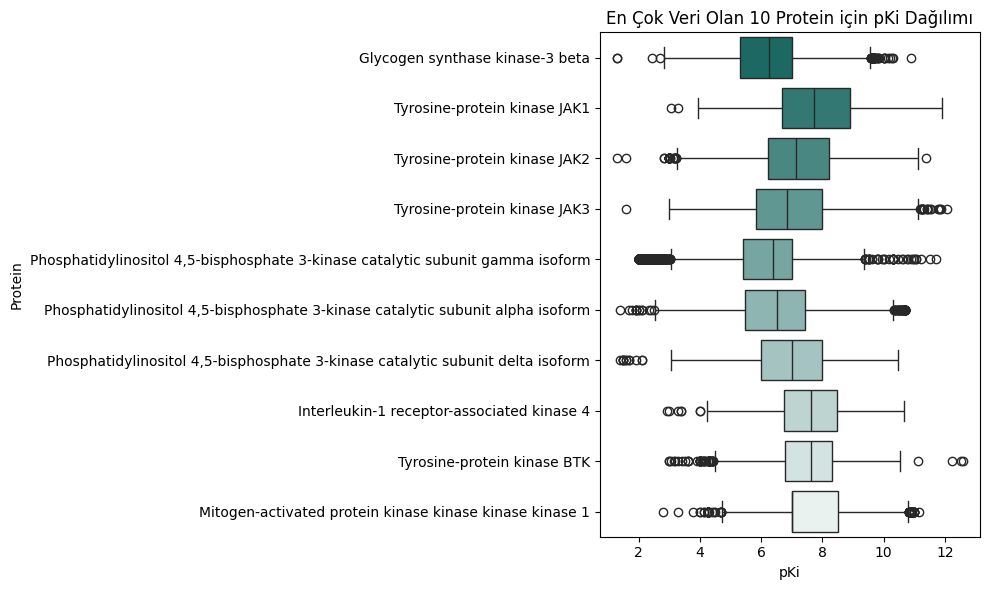

In [205]:
top_proteins = combined['protein'].value_counts().head(10).index
subset = combined[combined['protein'].isin(top_proteins)]

petrol_tonlari = sns.light_palette('#0f766e', n_colors=10, reverse=True)

plt.figure(figsize=(10, 6))
sns.boxplot(data=subset, x='pKi', y='protein', palette=petrol_tonlari)
plt.xlabel('pKi')
plt.ylabel('Protein')
plt.title('En Çok Veri Olan 10 Protein için pKi Dağılımı')
plt.tight_layout()
plt.show()

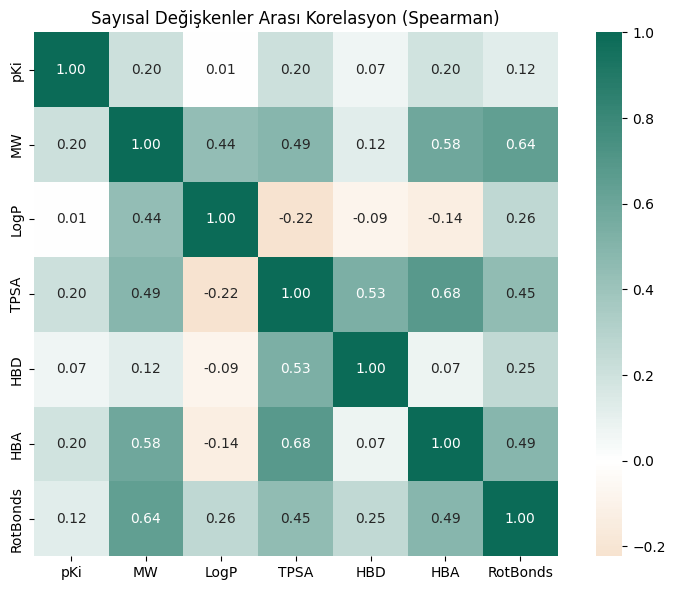

In [206]:
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = ['pKi', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds']
corr_matrix = combined[numeric_cols].corr(method='spearman')

cmap = LinearSegmentedColormap.from_list('turuncu_petrol', ['#D9822B', '#FFFFFF', '#0B6B57'])

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap, center=0, square=True)
plt.title('Sayısal Değişkenler Arası Korelasyon (Spearman)')
plt.tight_layout()
plt.show()

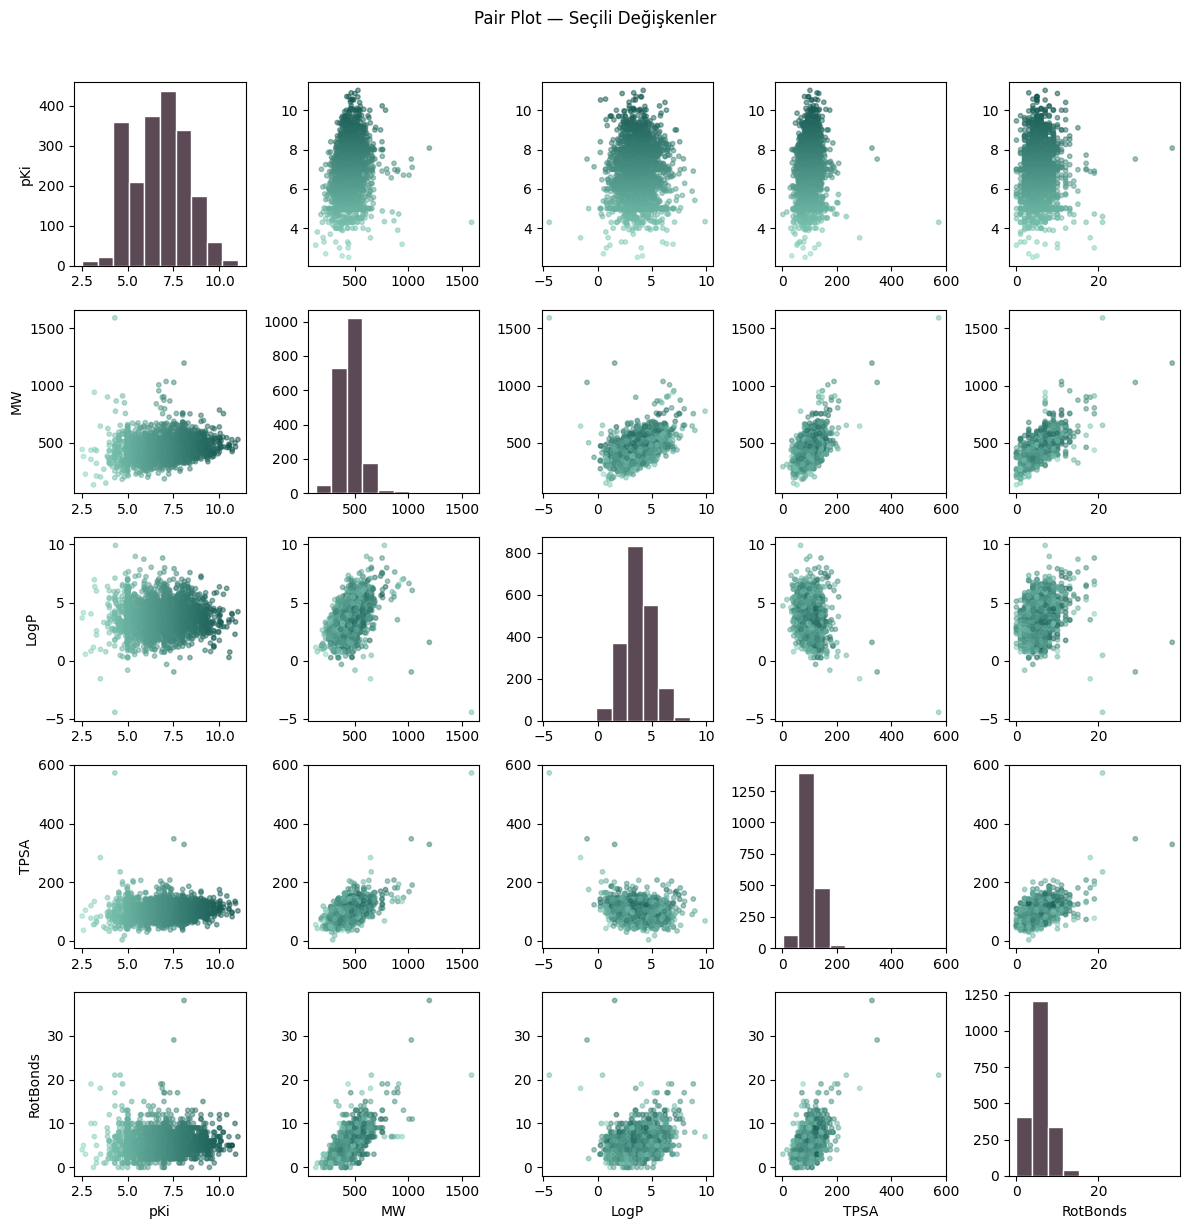

In [226]:
from matplotlib.colors import LinearSegmentedColormap

petrol_cmap = LinearSegmentedColormap.from_list('petrol_mint', ['#8FD9C4', '#0A4D47'])

pairplot_sample = combined.sample(2000, random_state=42)
cols = ['pKi', 'MW', 'LogP', 'TPSA', 'RotBonds']
n = len(cols)

fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i == j:
            ax.hist(pairplot_sample[cols[i]], color='#5B4A55', edgecolor='white')
        else:
            ax.scatter(pairplot_sample[cols[j]], pairplot_sample[cols[i]],
                       c=pairplot_sample['pKi'], cmap=petrol_cmap, alpha=0.5, s=10)
        if i == n - 1:
            ax.set_xlabel(cols[j])
        if j == 0:
            ax.set_ylabel(cols[i])

plt.suptitle('Pair Plot — Seçili Değişkenler', y=1.02)
plt.tight_layout()
plt.show()

In [227]:
from scipy import stats

# Shapiro-Wilk çok büyük veri setlerinde (>5000) aşırı hassaslaşıyor, bu yüzden bir örneklem üzerinde test ediyoruz
sample_for_test = combined['pKi'].sample(5000, random_state=42)

stat, p_value = stats.shapiro(sample_for_test)
print(f"Shapiro-Wilk istatistiği: {stat:.4f}")
print(f"p-değeri: {p_value:.10f}")

if p_value < 0.05:
    print("Sonuç: pKi normal dağılmıyor (p < 0.05)")
else:
    print("Sonuç: pKi normal dağılıma yakın (p >= 0.05)")

Shapiro-Wilk istatistiği: 0.9861
p-değeri: 0.0000000000
Sonuç: pKi normal dağılmıyor (p < 0.05)


In [228]:
from scipy.stats import spearmanr

hypotheses = {
    'H1 (MW vs pKi)': 'MW',
    'H2 (LogP vs pKi)': 'LogP',
    'H3 (TPSA vs pKi)': 'TPSA',
}

for name, col in hypotheses.items():
    corr, p = spearmanr(combined[col], combined['pKi'])
    sonuc = "Anlamlı (p < 0.05)" if p < 0.05 else "Anlamlı değil (p >= 0.05)"
    print(f"{name}: korelasyon={corr:.3f}, p-değeri={p:.2e} → {sonuc}")

H1 (MW vs pKi): korelasyon=0.204, p-değeri=0.00e+00 → Anlamlı (p < 0.05)
H2 (LogP vs pKi): korelasyon=0.010, p-değeri=2.37e-12 → Anlamlı (p < 0.05)
H3 (TPSA vs pKi): korelasyon=0.205, p-değeri=0.00e+00 → Anlamlı (p < 0.05)


In [229]:
corr, p = spearmanr(combined['HBA'], combined['pKi'])
sonuc = "Anlamlı (p < 0.05)" if p < 0.05 else "Anlamlı değil (p >= 0.05)"
print(f"H4 (HBA vs pKi): korelasyon={corr:.3f}, p-değeri={p:.2e} → {sonuc}")

H4 (HBA vs pKi): korelasyon=0.196, p-değeri=0.00e+00 → Anlamlı (p < 0.05)


In [230]:
from scipy.stats import kruskal

groups = [subset[subset['protein'] == protein]['pKi'] for protein in top_proteins]

stat, p = kruskal(*groups)
sonuc = "Anlamlı (p < 0.05)" if p < 0.05 else "Anlamlı değil (p >= 0.05)"
print(f"H5 (Protein grupları vs pKi): istatistik={stat:.2f}, p-değeri={p:.2e} -> {sonuc}")

H5 (Protein grupları vs pKi): istatistik=12322.09, p-değeri=0.00e+00 -> Anlamlı (p < 0.05)


In [231]:
## 10. Makine Öğrenmesi

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds']
X = combined[features]
y = combined['pKi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (431374, 6)
Test seti: (107844, 6)


In [232]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression — R²: {r2_lr:.4f}, RMSE: {rmse_lr:.4f}, MAE: {mae_lr:.4f}")

Linear Regression — R²: 0.0486, RMSE: 1.4125, MAE: 1.1594


In [233]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print(f"Ridge — R²: {r2_ridge:.4f}, RMSE: {rmse_ridge:.4f}, MAE: {mae_ridge:.4f}")

# Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"Lasso — R²: {r2_lasso:.4f}, RMSE: {rmse_lasso:.4f}, MAE: {mae_lasso:.4f}")

Ridge — R²: 0.0486, RMSE: 1.4125, MAE: 1.1594
Lasso — R²: 0.0481, RMSE: 1.4129, MAE: 1.1605


In [234]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt_train = dt.predict(X_train)
y_pred_dt_test = dt.predict(X_test)

r2_dt_train = r2_score(y_train, y_pred_dt_train)
r2_dt_test = r2_score(y_test, y_pred_dt_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt_test))
mae_dt = mean_absolute_error(y_test, y_pred_dt_test)

print(f"Decision Tree — Eğitim R²: {r2_dt_train:.4f}, Test R²: {r2_dt_test:.4f}")
print(f"Decision Tree — Test RMSE: {rmse_dt:.4f}, Test MAE: {mae_dt:.4f}")

Decision Tree — Eğitim R²: 0.8289, Test R²: 0.3340
Decision Tree — Test RMSE: 1.1818, Test MAE: 0.8261


In [235]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf = mean_absolute_error(y_test, y_pred_rf_test)

print(f"Random Forest — Eğitim R²: {r2_rf_train:.4f}, Test R²: {r2_rf_test:.4f}")
print(f"Random Forest — Test RMSE: {rmse_rf:.4f}, Test MAE: {mae_rf:.4f}")

Random Forest — Eğitim R²: 0.8002, Test R²: 0.5171
Random Forest — Test RMSE: 1.0063, Test MAE: 0.7425


In [236]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb_train = gb.predict(X_train)
y_pred_gb_test = gb.predict(X_test)

r2_gb_train = r2_score(y_train, y_pred_gb_train)
r2_gb_test = r2_score(y_test, y_pred_gb_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb_test))
mae_gb = mean_absolute_error(y_test, y_pred_gb_test)

print(f"Gradient Boosting — Eğitim R²: {r2_gb_train:.4f}, Test R²: {r2_gb_test:.4f}")
print(f"Gradient Boosting — Test RMSE: {rmse_gb:.4f}, Test MAE: {mae_gb:.4f}")

Gradient Boosting — Eğitim R²: 0.1512, Test R²: 0.1486
Gradient Boosting — Test RMSE: 1.3362, Test MAE: 1.0904


In [237]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R2': [r2_lr, r2_ridge, r2_lasso, r2_dt_test, r2_rf_test, r2_gb_test],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_dt, rmse_rf, rmse_gb],
    'MAE': [mae_lr, mae_ridge, mae_lasso, mae_dt, mae_rf, mae_gb]
}).sort_values('R2', ascending=False)

results

,Model,R2,RMSE,MAE
4,Random Forest,0.517135,1.006282,0.742546
3,Decision Tree,0.334008,1.181792,0.826052
5,Gradient Boosting,0.148582,1.336221,1.090392
0,Linear Regression,0.048627,1.412480,1.159444
1,Ridge,0.048627,1.412480,1.159444
2,Lasso,0.048112,1.412862,1.160540


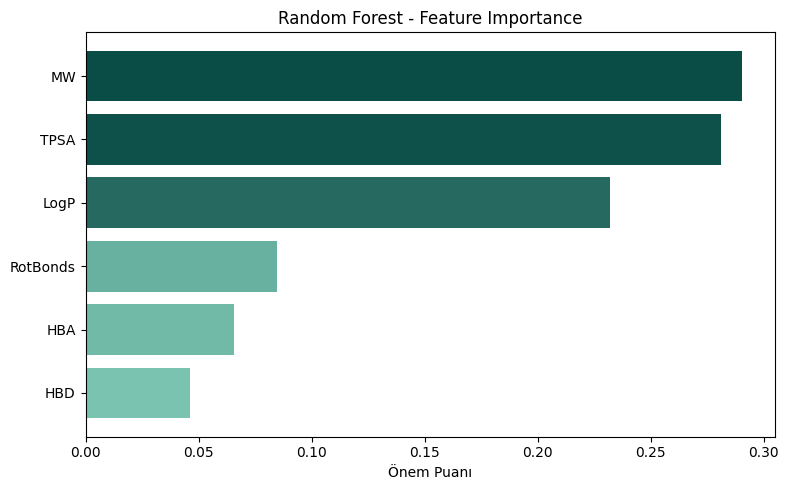

,Özellik,Önem
0,MW,0.290527
1,TPSA,0.281145
2,LogP,0.231882
3,RotBonds,0.084525
4,HBA,0.065595
5,HBD,0.046327


In [238]:
from matplotlib.colors import LinearSegmentedColormap

importances = pd.DataFrame({
    'Özellik': features,
    'Önem': rf.feature_importances_
}).sort_values('Önem', ascending=False).reset_index(drop=True)

cmap = LinearSegmentedColormap.from_list('petrol_mint', ['#8FD9C4', '#0A4D47'])
renkler = cmap(importances['Önem'] / importances['Önem'].max())

plt.figure(figsize=(8, 5))
plt.barh(importances['Özellik'], importances['Önem'], color=renkler)
plt.xlabel('Önem Puanı')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

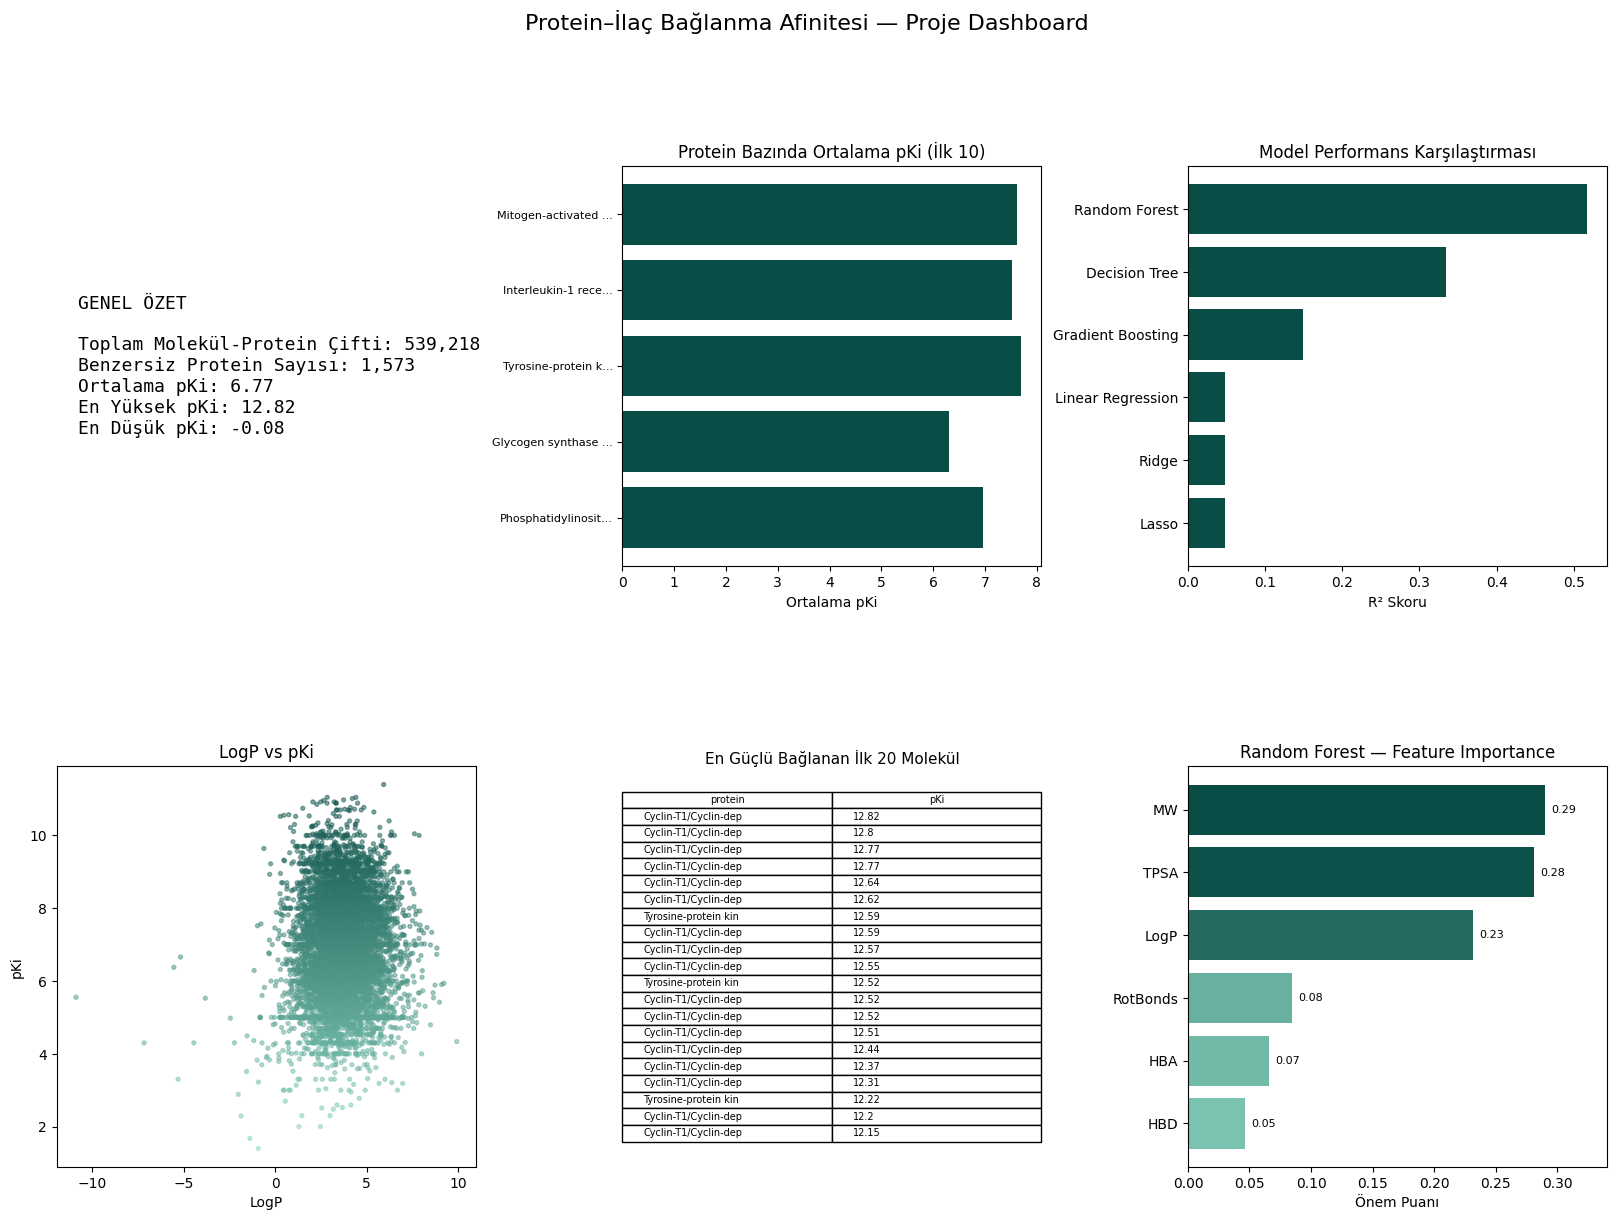

In [243]:
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(2, 3, figsize=(20, 13), gridspec_kw={'hspace': 0.5, 'wspace': 0.35})

petrol_cmap = LinearSegmentedColormap.from_list('petrol_mint', ['#8FD9C4', '#0A4D47'])

# Panel 1: Genel Özet (metin)
ax1 = axes[0, 0]
ax1.axis('off')
ozet_metni = (
    f"GENEL ÖZET\n\n"
    f"Toplam Molekül-Protein Çifti: {len(combined):,}\n"
    f"Benzersiz Protein Sayısı: {combined['protein'].nunique():,}\n"
    f"Ortalama pKi: {combined['pKi'].mean():.2f}\n"
    f"En Yüksek pKi: {combined['pKi'].max():.2f}\n"
    f"En Düşük pKi: {combined['pKi'].min():.2f}"
)
ax1.text(0.05, 0.5, ozet_metni, fontsize=13, va='center', family='monospace')

# Panel 2: Protein bazında ortalama pKi
ax2 = axes[0, 1]
protein_ortalama = subset.groupby('protein')['pKi'].mean().sort_values()
kisa_isimler = [p[:18] + '...' if len(p) > 18 else p for p in protein_ortalama.index]
ax2.barh(kisa_isimler, protein_ortalama.values, color='#0A4D47')
ax2.set_xlabel('Ortalama pKi')
ax2.set_title('Protein Bazında Ortalama pKi (İlk 10)')
ax2.tick_params(axis='y', labelsize=8)

# Panel 3: Model performans karşılaştırması
ax3 = axes[0, 2]
ax3.barh(results['Model'], results['R2'], color='#0A4D47')
ax3.set_xlabel('R² Skoru')
ax3.set_title('Model Performans Karşılaştırması')
ax3.invert_yaxis()

# Panel 4: LogP vs pKi (gradyanlı)
ax4 = axes[1, 0]
ax4.scatter(sample['LogP'], sample['pKi'], alpha=0.5, s=8, c=sample['pKi'], cmap=petrol_cmap)
ax4.set_xlabel('LogP')
ax4.set_ylabel('pKi')
ax4.set_title('LogP vs pKi')

# Panel 5: En güçlü bağlanan ilk 20 molekül (tablo)
ax5 = axes[1, 1]
ax5.axis('off')
top20 = combined.nlargest(20, 'pKi')[['protein', 'pKi']].reset_index(drop=True)
top20['protein'] = top20['protein'].str[:20]
tablo = ax5.table(cellText=top20.round(2).values, colLabels=top20.columns,
                   loc='center', cellLoc='left')
tablo.auto_set_font_size(False)
tablo.set_fontsize(7)
ax5.set_title('En Güçlü Bağlanan İlk 20 Molekül', pad=2, fontsize=11)

# Panel 6: Feature Importance (gradyanlı + değer etiketli)
ax6 = axes[1, 2]
renkler = petrol_cmap(importances['Önem'] / importances['Önem'].max())
bars6 = ax6.barh(importances['Özellik'], importances['Önem'], color=renkler)
for bar, deger in zip(bars6, importances['Önem']):
    ax6.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
              f'{deger:.2f}', va='center', fontsize=8)
ax6.set_xlabel('Önem Puanı')
ax6.set_title('Random Forest — Feature Importance')
ax6.invert_yaxis()
ax6.set_xlim(0, importances['Önem'].max() + 0.05)

plt.suptitle('Protein–İlaç Bağlanma Afinitesi — Proje Dashboard', fontsize=16, y=1.0)
plt.savefig(DATA_DIR + '../dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [240]:
plt.suptitle('Protein–İlaç Bağlanma Afinitesi — Proje Dashboard', fontsize=16, y=1.0)
plt.savefig(DATA_DIR + '../dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>